# Task 2: Sentiment Analysis, Thematic Mapping & Data Visualization
## 10 Academy Week 2 Challenge: Fintech Customer Experience Analytics

This notebook implements the Natural Language Processing (NLP) pipeline to evaluate user feedback across CBE, BOA, and Dashen Bank. 
We use the lexicon-based **VADER Sentiment Analysis** model and execute keyword-based thematic extraction to segment user pain points into five primary fintech domains.

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Ingest Cleaned Dataset

In [2]:
df = pd.read_csv('../data/raw/cleaned_reviews.csv')
print(f"Loaded {len(df)} cleaned records.")

Loaded 1705 cleaned records.


## Run VADER Sentiment Classifier
VADER assigns compound sentiment scores between -1.0 (highly negative) and +1.0 (highly positive).

In [3]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    if not isinstance(text, str):
        return 'neutral', 0.0
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive', score
    elif score <= -0.05:
        return 'negative', score
    else:
        return 'neutral', score

sentiments = [get_vader_sentiment(t) for t in df['review']]
df['sentiment_label'] = [s[0] for s in sentiments]
df['sentiment_score'] = [s[1] for s in sentiments]

print("Sentiment classification completed.")

Sentiment classification completed.


## Run Thematic extraction mapping
We classify user feedback into 5 major categories:
1. `Account Access & Authentication` (login, OTP, register)
2. `Transaction & Payment Issues` (transfer, send, deposit, balance, fee)
3. `App Performance & Stability` (crash, slow, freeze, error)
4. `UI & Customer Experience` (interface, modern, design, update)
5. `Customer Support & Service` (call, customer, response, service)

In [4]:
themes = {
    'Account Access & Authentication': ['login', 'log in', 'otp', 'code', 'password', 'pin', 'register', 'verification', 'opened'],
    'Transaction & Payment Issues': ['transfer', 'send', 'payment', 'fee', 'charge', 'money', 'transaction', 'balance', 'deduct', 'receive', 'pay', 'double'],
    'App Performance & Stability': ['crash', 'slow', 'freeze', 'loading', 'network', 'error', 'bug', 'connection', 'open', 'worst', 'bad'],
    'UI & Customer Experience': ['ui', 'ux', 'interface', 'beautiful', 'clean', 'design', 'update', 'awesome', 'good', 'nice', 'easy'],
    'Customer Support & Service': ['support', 'customer', 'care', 'agent', 'help', 'response', 'bank', 'service', 'branch']
}

def map_theme(text):
    if not isinstance(text, str):
        return 'Other / General Feedback'
    text_lower = text.lower()
    for theme, keywords in themes.items():
        for kw in keywords:
            if kw in text_lower:
                return theme
    return 'Other / General Feedback'

df['identified_theme'] = [map_theme(t) for t in df['review']]
print("Thematic extraction mapping completed.")

Thematic extraction mapping completed.


## Save Results

In [5]:
df.to_csv('../data/raw/sentiment_reviews.csv', index=False)
print("Saved results to '../data/raw/sentiment_reviews.csv'.")

Saved results to '../data/raw/sentiment_reviews.csv'.


## Generate Plot Visualizations

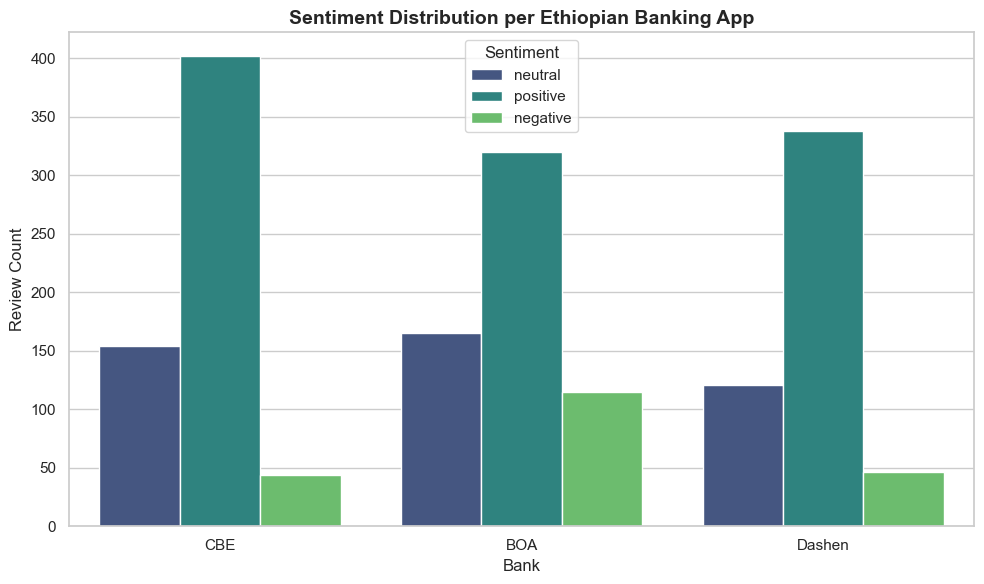

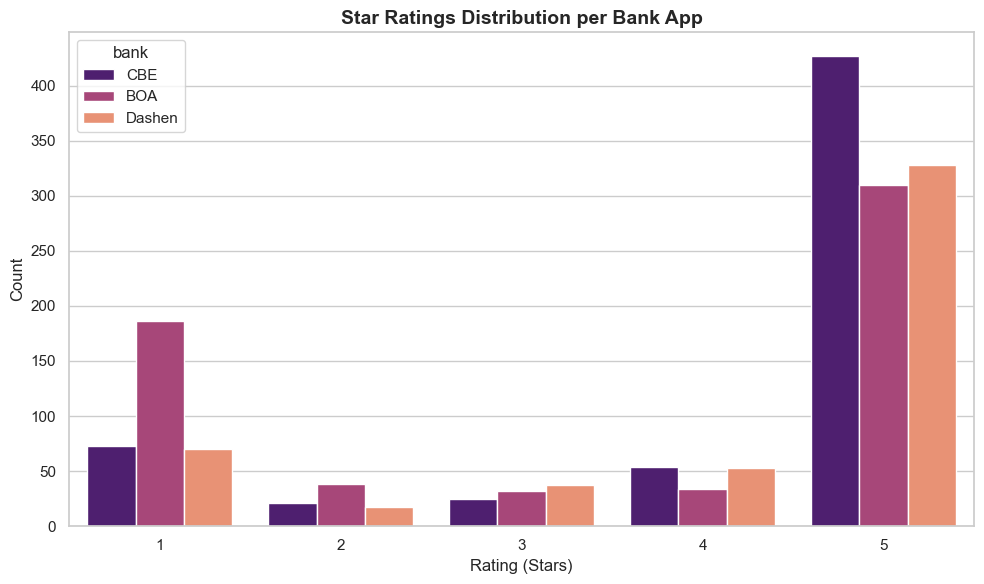

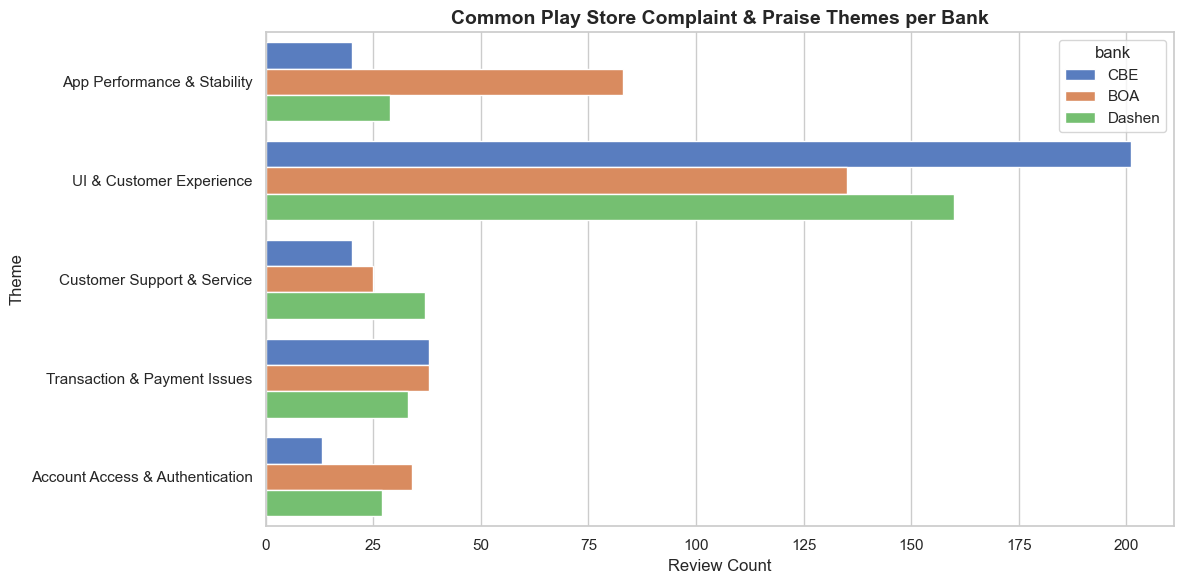

In [6]:
sns.set_theme(style="whitegrid")

# Plot 1: Sentiment Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='bank', hue='sentiment_label', palette='viridis')
plt.title('Sentiment Distribution per Ethiopian Banking App', fontsize=14, fontweight='bold')
plt.xlabel('Bank', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('../notebooks/plots/sentiment_distribution.png')
plt.show()

# Plot 2: Rating star Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', hue='bank', palette='magma')
plt.title('Star Ratings Distribution per Bank App', fontsize=14, fontweight='bold')
plt.xlabel('Rating (Stars)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/plots/ratings_by_bank.png')
plt.show()

# Plot 3: Themes Frequency
plt.figure(figsize=(12, 6))
theme_counts = df[df['identified_theme'] != 'Other / General Feedback']
sns.countplot(data=theme_counts, y='identified_theme', hue='bank', palette='muted')
plt.title('Common Play Store Complaint & Praise Themes per Bank', fontsize=14, fontweight='bold')
plt.xlabel('Review Count', fontsize=12)
plt.ylabel('Theme', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/plots/themes_frequency.png')
plt.show()